<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Practica21_Overfitting_y_Underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 21: Práctica de Generalización, Overfitting y Underfitting

Nombre: Oscar Morales Martinez

Materia: Programación para analítica descriptiva y predictiva

Carrera: Maestría en Inteligencia Artificial y Analítica de Datos

## Instrucciones:

Tomando como ejemplo el cuaderno que se compartió en los recursos. Realiza ahora los siguientes ejercicios:

* Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.05
* Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20
* En qué valores de max_depth se observa un overfitting y un underfitting
* Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.40
* Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20
* En qué valores de max_depth se observa un overfitting y un underfitting

Paso 1: Importar librerias

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
# Loss 0-1 = 1 - accuracy
def loss_01(y_true, y_pred):
    """Fraccion de ejemplos mal clasificados."""
    return 1.0 - accuracy_score(y_true, y_pred)

print('Listo.')

Listo.


## noise = 0.005

Paso 1: Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.05

In [10]:
# Generamos el dataset
np.random.seed(42)

#X tiene el conjunto de datos de M x N
#Y es el vector de clases
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Split 70 / 30
# 70% datos de Entrenamiento
# 30% Datos de test
#Devuelve 4 archivos: 2 del conjunto de datos en entrenamiento y test,
# y otros 2 con las etiquetas de clase de entrenamiento y test
# con Random_state agregarmos una semilla
# Estratificamos para cumplir con las probabilidades a priori en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Train: {X_train.shape[0]} ejemplos')
print(f'Test:  {X_test.shape[0]} ejemplos')
print(f'Clases: {np.bincount(y_train)} en train   {np.bincount(y_test)} en test')

Train: 210 ejemplos
Test:  90 ejemplos
Clases: [112  98] en train   [38 52] en test


Paso 2: Visualizamos el dataset

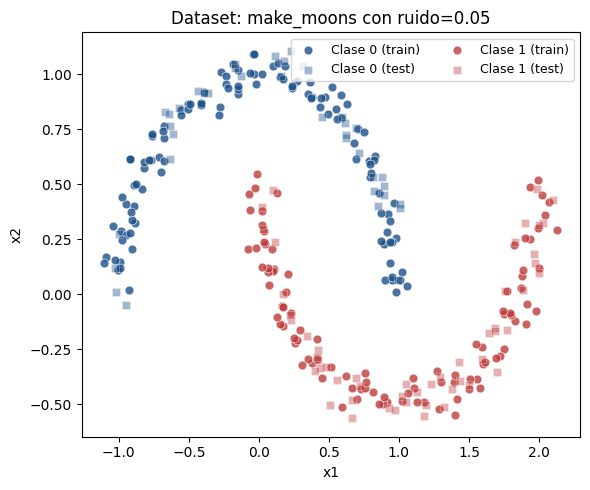

In [11]:
# Visualizamos el dataset
fig, ax = plt.subplots(figsize=(6, 5))

cmap_pts = ['#1B4F8A', '#BF3B3B']
for clase, color, label in [(0, '#1B4F8A', 'Clase 0'), (1, '#BF3B3B', 'Clase 1')]:
    mask = y_train == clase
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=color, s=40, alpha=0.8, edgecolors='white', lw=0.5, label=f'{label} (train)')
    mask_te = y_test == clase
    ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
               c=color, s=40, alpha=0.4, edgecolors='white', lw=0.5,
               marker='s', label=f'{label} (test)')

ax.set_title('Dataset: make_moons con ruido=0.05', fontsize=12)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

Paso 3: Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20

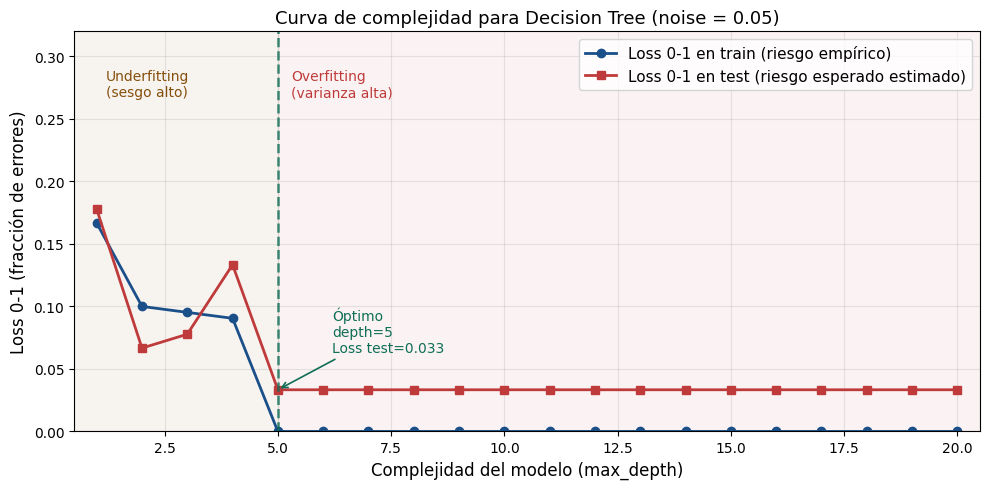

In [12]:
# Curva de complejidad
profundidades = list(range(1, 21))
loss_trains, loss_tests = [], []

for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_train, y_train)
    loss_trains.append(loss_01(y_train, modelo.predict(X_train)))
    loss_tests.append(loss_01(y_test, modelo.predict(X_test)))

idx_opt = int(np.argmin(loss_tests))
depth_opt = profundidades[idx_opt]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profundidades, loss_trains, 'o-', color='#1B4F8A',
        lw=2, ms=6, label='Loss 0-1 en train (riesgo empírico)')
ax.plot(profundidades, loss_tests, 's-', color='#BF3B3B',
        lw=2, ms=6, label='Loss 0-1 en test (riesgo esperado estimado)')

# Punto óptimo
ax.axvline(depth_opt, color='#0F6E56', lw=1.8, ls='--', alpha=0.8)
ax.annotate(
    f'Óptimo\ndepth={depth_opt}\nLoss test={loss_tests[idx_opt]:.3f}',
    xy=(depth_opt, loss_tests[idx_opt]),
    xytext=(depth_opt + 1.2, loss_tests[idx_opt] + 0.03),
    fontsize=10, color='#0F6E56',
    arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.2)
)

# Zonas
ax.axvspan(0.5, depth_opt, alpha=0.06, color='#854F0B')
ax.axvspan(depth_opt, 20.5, alpha=0.06, color='#BF3B3B')

ax.text(1.2, 0.29, 'Underfitting\n(sesgo alto)', fontsize=10, color='#854F0B', va='top')
ax.text(depth_opt + 0.3, 0.29, 'Overfitting\n(varianza alta)', fontsize=10, color='#BF3B3B', va='top')

ax.set_xlabel('Complejidad del modelo (max_depth)', fontsize=12)
ax.set_ylabel('Loss 0-1 (fracción de errores)', fontsize=12)
ax.set_title('Curva de complejidad para Decision Tree (noise = 0.05)', fontsize=13)
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0, 0.32)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**En qué valores de max_depth se observa un overfitting y un underfitting:**

* Underfitting en profundidades bajas, típicamente max_depth = 1 a 2
* Mejor balance cerca del mínimo de la curva de test
* Overfitting en profundidades altas, cuando el error de train sigue bajando pero el de test sube

## noise = 0.40

Paso 1: Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.40

In [13]:
# Generamos el dataset
np.random.seed(42)

#X tiene el conjunto de datos de M x N
#Y es el vector de clases
X, y = make_moons(n_samples=300, noise=0.40, random_state=42)

# Split 70 / 30
# 70% datos de Entrenamiento
# 30% Datos de test
#Devuelve 4 archivos: 2 del conjunto de datos en entrenamiento y test,
# y otros 2 con las etiquetas de clase de entrenamiento y test
# con Random_state agregarmos una semilla
# Estratificamos para cumplir con las probabilidades a priori en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Train: {X_train.shape[0]} ejemplos')
print(f'Test:  {X_test.shape[0]} ejemplos')
print(f'Clases: {np.bincount(y_train)} en train   {np.bincount(y_test)} en test')

Train: 210 ejemplos
Test:  90 ejemplos
Clases: [112  98] en train   [38 52] en test


Paso 2: Visualizamos el dataset

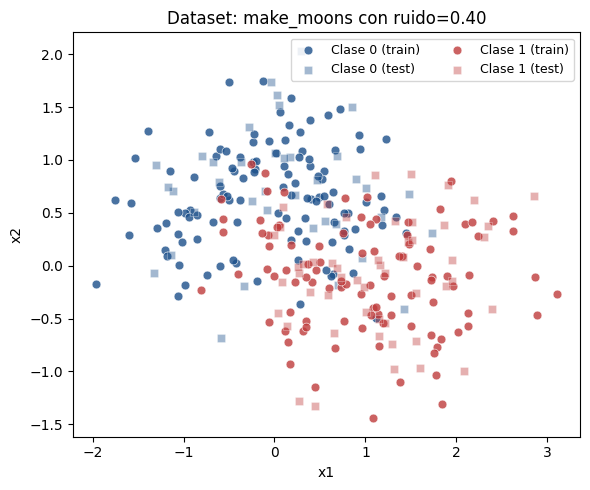

In [14]:
# Visualizamos el dataset
fig, ax = plt.subplots(figsize=(6, 5))

cmap_pts = ['#1B4F8A', '#BF3B3B']
for clase, color, label in [(0, '#1B4F8A', 'Clase 0'), (1, '#BF3B3B', 'Clase 1')]:
    mask = y_train == clase
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=color, s=40, alpha=0.8, edgecolors='white', lw=0.5, label=f'{label} (train)')
    mask_te = y_test == clase
    ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
               c=color, s=40, alpha=0.4, edgecolors='white', lw=0.5,
               marker='s', label=f'{label} (test)')

ax.set_title('Dataset: make_moons con ruido=0.40', fontsize=12)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

Paso 3: Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20

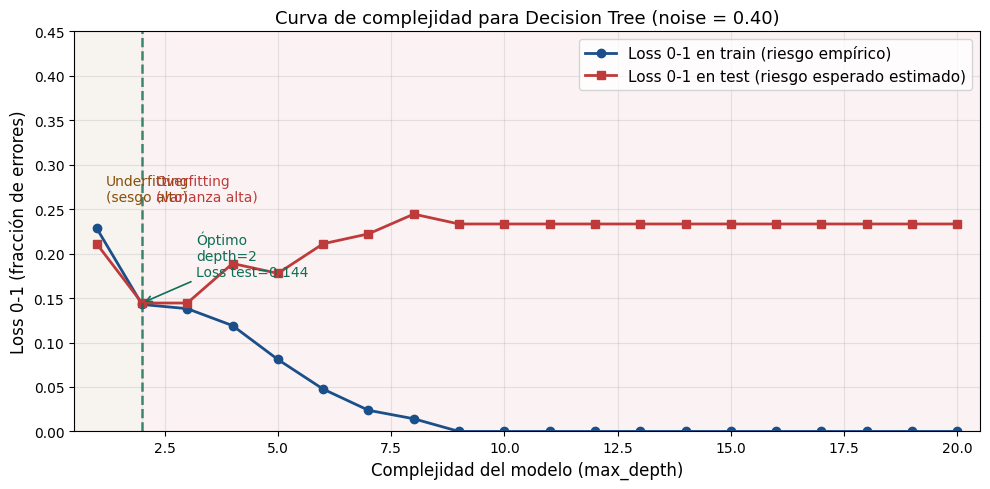

In [15]:
# Curva de complejidad
profundidades = list(range(1, 21))
loss_trains, loss_tests = [], []

for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_train, y_train)
    loss_trains.append(loss_01(y_train, modelo.predict(X_train)))
    loss_tests.append(loss_01(y_test, modelo.predict(X_test)))

idx_opt = int(np.argmin(loss_tests))
depth_opt = profundidades[idx_opt]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profundidades, loss_trains, 'o-', color='#1B4F8A',
        lw=2, ms=6, label='Loss 0-1 en train (riesgo empírico)')
ax.plot(profundidades, loss_tests, 's-', color='#BF3B3B',
        lw=2, ms=6, label='Loss 0-1 en test (riesgo esperado estimado)')

# Punto óptimo
ax.axvline(depth_opt, color='#0F6E56', lw=1.8, ls='--', alpha=0.8)
ax.annotate(
    f'Óptimo\ndepth={depth_opt}\nLoss test={loss_tests[idx_opt]:.3f}',
    xy=(depth_opt, loss_tests[idx_opt]),
    xytext=(depth_opt + 1.2, loss_tests[idx_opt] + 0.03),
    fontsize=10, color='#0F6E56',
    arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.2)
)

# Zonas
ax.axvspan(0.5, depth_opt, alpha=0.06, color='#854F0B')
ax.axvspan(depth_opt, 20.5, alpha=0.06, color='#BF3B3B')

ax.text(1.2, 0.29, 'Underfitting\n(sesgo alto)', fontsize=10, color='#854F0B', va='top')
ax.text(depth_opt + 0.3, 0.29, 'Overfitting\n(varianza alta)', fontsize=10, color='#BF3B3B', va='top')

ax.set_xlabel('Complejidad del modelo (max_depth)', fontsize=12)
ax.set_ylabel('Loss 0-1 (fracción de errores)', fontsize=12)
ax.set_title('Curva de complejidad para Decision Tree (noise = 0.40)', fontsize=13)
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0, 0.45)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**En qué valores de max_depth se observa un overfitting y un underfitting:**

* Underfitting también en profundidades bajas
* Overfitting aparece antes que en el caso anterior, porque hay más ruido
* El mejor modelo suele estar en una profundidad menor o intermedia